# Projet Final Deep Learning
## EMSI 2025-2026

Réalisé par : fatima ezzahrae aitelhaj



Module : Deep Learning

Ce projet vise à étudier trois grandes familles de réseaux de neurones :

- MLP pour les données tabulaires
- CNN pour les images
- RNN/LSTM/GRU pour les données séquentielles

L'objectif est de comprendre les différences théoriques et pratiques entre ces architectures.

## PARTIE I — MLP
1.1 Théorie

Expliquer :

neurone
perceptron
fonction d'activation
propagation avant
rétropropagation

## Importer les bibliothèques

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

1.2 Dataset

Breast Cancer Dataset

In [ ]:
from sklearn.datasets import load_breast_cancer

## Charger le Dataset

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


## Comprendre les données

In [ ]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [ ]:
print(data.target_names)

['malignant' 'benign']


## Séparer Train/Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

###  Vérification

In [ ]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


## Normaliser les données
Très important pour un MLP.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Convertir en Tensor PyTorch

In [ ]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

## Construire le MLP

In [ ]:
class BreastCancerMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(30, 64),

            nn.ReLU(),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Linear(32, 1),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.network(x)

## Créer le modèle

In [ ]:
model = BreastCancerMLP()

print(model)

BreastCancerMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## Fonction de perte et optimiseur


In [ ]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Entraîner le modèle

In [ ]:
losses = []

epochs = 100

for epoch in range(epochs):

    outputs = model(X_train)

    loss = criterion(
        outputs.squeeze(),
        y_train
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss={loss.item():.4f}"
        )

Epoch 0 Loss=0.6787
Epoch 10 Loss=0.5600
Epoch 20 Loss=0.4265
Epoch 30 Loss=0.2926
Epoch 40 Loss=0.1932
Epoch 50 Loss=0.1347
Epoch 60 Loss=0.1020
Epoch 70 Loss=0.0833
Epoch 80 Loss=0.0718
Epoch 90 Loss=0.0638


## Courbe de Loss

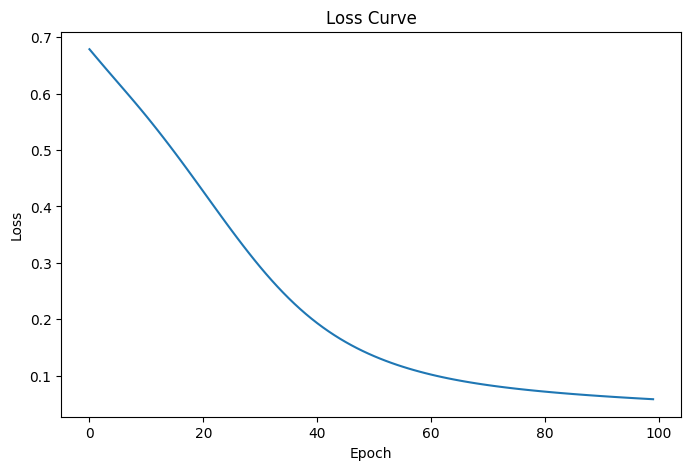

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

## Évaluer le modèle

In [ ]:
with torch.no_grad():

    predictions = model(X_test)

    predictions = (
        predictions.squeeze() > 0.5
    ).float()

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy :",
    accuracy
)

Accuracy : 0.9912280701754386


## PARTIE II — CNN FASHION-MNIST

### Importer les bibliothèques

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

### Vérifier le GPU

Le sujet valorise l'utilisation du GPU

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


### Prétraitement + Data Augmentation

In [ ]:
transform_train = transforms.Compose([

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

### Télécharger Fashion-MNIST

In [ ]:
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

### Créer les DataLoaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

### Visualiser les images

In [ ]:
classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

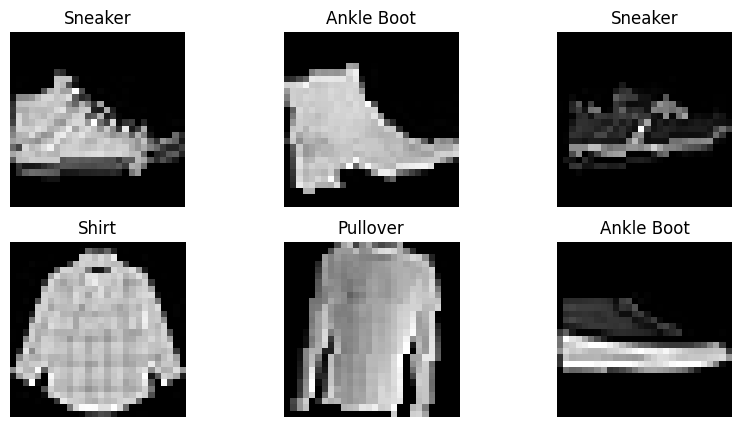

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        classes[labels[i]]
    )

    plt.axis("off")

plt.show()

### Construire le CNN

In [ ]:
class FashionCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64*7*7,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                10
            )
        )

    def forward(self,x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

### Créer le modèle

In [ ]:
model = FashionCNN().to(device)

print(model)

FashionCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Loss et Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### Early Stopping

In [ ]:
best_loss = float("inf")

patience = 3

counter = 0

### Entraînement

In [ ]:
num_epochs = 15

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1} "
        f"Loss={epoch_loss:.4f}"
    )

    if epoch_loss < best_loss:

        best_loss = epoch_loss

        counter = 0

    else:

        counter += 1

        if counter >= patience:

            print("Early Stopping")

            break

Epoch 1 Loss=0.5868
Epoch 2 Loss=0.3937
Epoch 3 Loss=0.3408
Epoch 4 Loss=0.3088
Epoch 5 Loss=0.2900
Epoch 6 Loss=0.2743
Epoch 7 Loss=0.2638
Epoch 8 Loss=0.2531
Epoch 9 Loss=0.2417
Epoch 10 Loss=0.2374
Epoch 11 Loss=0.2322
Epoch 12 Loss=0.2260
Epoch 13 Loss=0.2207
Epoch 14 Loss=0.2175
Epoch 15 Loss=0.2114


### Courbe Loss

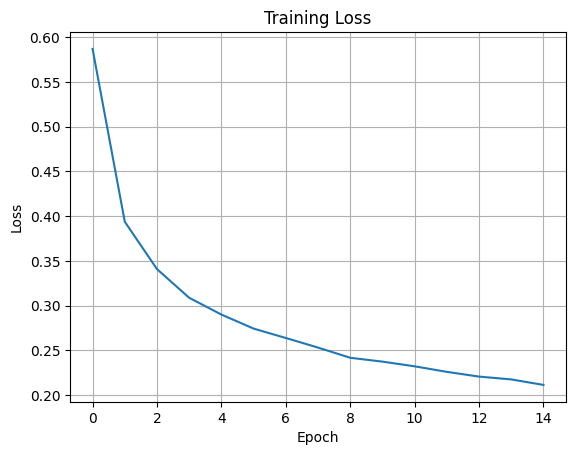

In [66]:
plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

### Accuracy

In [67]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Accuracy = {accuracy:.2f}%"
)

Accuracy = 91.85%


### Matrice de confusion

In [68]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

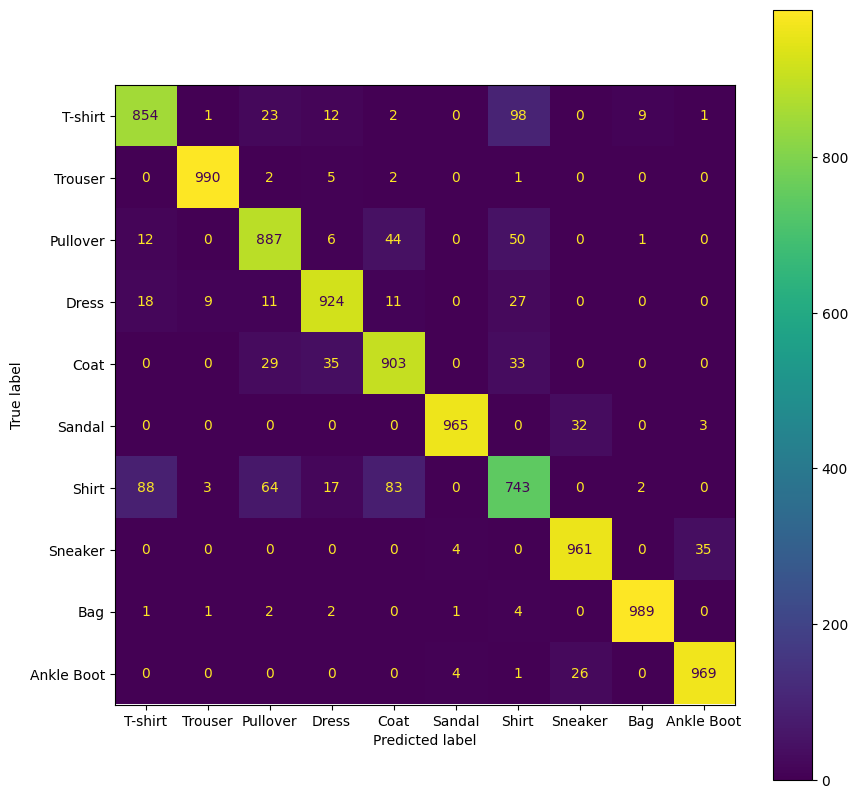

In [69]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(
    figsize=(10,10)
)

disp.plot(ax=ax)

plt.show()

### Sauvegarder

In [70]:
torch.save(
    model.state_dict(),
    "fashion_cnn.pth"
)

#Partie III

Construire un mini système de traduction :

English  →  French

Exemples :

* hello          → bonjour
* good night     → bonne nuit
* thank you      → merci
* how are you    → comment  allez-vous

Cette partie permettra de montrer :

RNN
LSTM
GRU
Seq2Seq
Encodage / Décodage
Évaluation

### Importer les bibliothèques

In [71]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np

from collections import Counter

In [72]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


### Créer un mini dataset

In [73]:
pairs = [

("hello","bonjour"),
("good morning","bonjour"),
("good night","bonne nuit"),
("thank you","merci"),
("see you","à bientôt"),
("how are you","comment allez vous"),
("i love you","je t aime"),
("goodbye","au revoir"),
("yes","oui"),
("no","non")
]

### Construire le vocabulaire

In [74]:
english_words = set()
french_words = set()

for eng, fr in pairs:

    english_words.update(
        eng.split()
    )

    french_words.update(
        fr.split()
    )

In [75]:
english_vocab = {
    "<PAD>":0,
    "<SOS>":1,
    "<EOS>":2
}

french_vocab = {
    "<PAD>":0,
    "<SOS>":1,
    "<EOS>":2
}

In [76]:
for word in english_words:

    english_vocab[word] = len(
        english_vocab
    )

for word in french_words:

    french_vocab[word] = len(
        french_vocab
    )

### Vérifier les vocabulaires

In [77]:
print(english_vocab)

print(french_vocab)

{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, 'love': 3, 'you': 4, 'morning': 5, 'are': 6, 'good': 7, 'i': 8, 'how': 9, 'yes': 10, 'hello': 11, 'thank': 12, 'no': 13, 'night': 14, 'goodbye': 15, 'see': 16}
{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, 'à': 3, 'bonne': 4, 't': 5, 'bonjour': 6, 'comment': 7, 'allez': 8, 'je': 9, 'non': 10, 'nuit': 11, 'aime': 12, 'vous': 13, 'revoir': 14, 'au': 15, 'oui': 16, 'bientôt': 17, 'merci': 18}


### Encoder les phrases

In [78]:
def encode(sentence, vocab):

    tokens = sentence.split()

    encoded = [
        vocab[word]
        for word in tokens
    ]

    encoded.append(
        vocab["<EOS>"]
    )

    return encoded

In [79]:
print(
    encode(
        "hello",
        english_vocab
    )
)

[11, 2]


  ### Préparer les données

In [80]:
X = []
Y = []

for eng, fr in pairs:

    X.append(
        encode(
            eng,
            english_vocab
        )
    )

    Y.append(
        encode(
            fr,
            french_vocab
        )
    )

### Définir un Encodeur RNN

In [81]:
class EncoderRNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_size,
        hidden_size
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_size
        )

        self.rnn = nn.RNN(
            embed_size,
            hidden_size,
            batch_first=True
        )

    def forward(self,x):

        x = self.embedding(x)

        outputs, hidden = self.rnn(x)

        return hidden

### Définir un Décodeur RNN

In [82]:
class DecoderRNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_size,
        hidden_size
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_size
        )

        self.rnn = nn.RNN(
            embed_size,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            vocab_size
        )

    def forward(
        self,
        x,
        hidden
    ):

        x = self.embedding(x)

        output, hidden = self.rnn(
            x,
            hidden
        )

        prediction = self.fc(
            output
        )

        return prediction, hidden

### Construire Seq2Seq

In [83]:
class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder
    ):

        super().__init__()

        self.encoder = encoder

        self.decoder = decoder

### Créer le modèle

In [84]:
encoder = EncoderRNN(
    len(english_vocab),
    16,
    32
)

decoder = DecoderRNN(
    len(french_vocab),
    16,
    32
)

model = Seq2Seq(
    encoder,
    decoder
)

### Comparaison RNN / LSTM / GRU

* RNN
Simple et rapide
mais souffre du problème
du gradient qui disparaît.
* LSTM
Ajoute des portes mémoire.
Conserve mieux l'information.
* GRU
Plus léger que LSTM.
Souvent aussi performant.